In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

In [2]:
class AgentState(TypedDict):
    number1:int
    number2:int
    operation:str
    result:int


In [3]:
def adder(state:AgentState)->AgentState:
    """This node adds two numbeers"""
    state['result']=state['number1']+state['number2']
    return state

def subtractor(state:AgentState)->AgentState:
    """This node subtracts two numbers"""
    state['result']=state['number1']-state['number2']
    return state

def decider(state:AgentState)->str:
    """This will decide the next node of the graph"""
    if state['operation']=="+":
        return "add_op"
    elif state['operation']=="-":
        return "subtract_op"
    

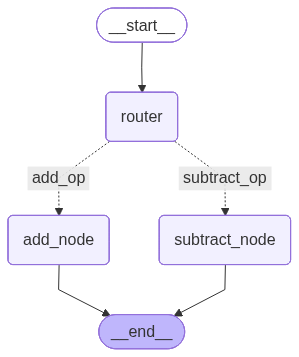

In [4]:
graph=StateGraph(AgentState)
graph.add_node("add_node",adder)
graph.add_node("subtract_node",subtractor)
graph.add_node("router",lambda state:state)
graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decider,
    {"add_op":"add_node","subtract_op":"subtract_node"}
)
graph.add_edge("add_node",END)
graph.add_edge("subtract_node",END)
bot=graph.compile()
bot

In [6]:
input_state={
    "number1":10,
    "number2":5,
    "operation":"+",
}
final_response=bot.invoke(input_state)
print(final_response)

{'number1': 10, 'number2': 5, 'operation': '+', 'result': 15}
